In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
# def diamond(n):
#     a = np.arange(n)
#     b = np.minimum(a,a[::-1])
#     return (b[:,None]+b)>=(n-1)//2

In [ ]:
def plus(ker_size):
    ker = np.zeros(ker_size,np.uint8)
    ker[ker_size[0] // 2] = np.ones(ker_size[1],np.uint8)
    ker[:,ker_size[1] // 2] = np.ones(ker_size[0],np.uint8)

    return ker

In [ ]:
def DilateBinary(img,ker_size = (5,5),shape = None,iter = 1):
    ker = np.ones(ker_size,np.uint8)
    if(shape == "plus"):
        ker = plus(ker_size)

    ker_h = ker.shape[0]
    ker_w = ker.shape[1]

    pad_h = ker_h // 2
    pad_w = ker_w // 2

    dil = np.zeros_like(img)

    pad_img = np.pad(img,((pad_h,pad_h),(pad_w,pad_w)),mode='constant', constant_values = 0 )

    for _ in range(iter):
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                reg = pad_img[i:i+ker_h,j:j+ker_w]
                if(np.any(reg & ker)):
                    dil[i,j] = 255
        pad_img = np.pad(dil,((pad_h,pad_h),(pad_w,pad_w)),mode='constant', constant_values = 0 )

    dil = dil.astype(np.uint8)
    return dil

In [ ]:
def ErodeBinary(img,ker_size = (5,5),shape = None,iter = 1):
    ker = np.ones(ker_size,np.uint8)
    if(shape == "plus"):
        ker = plus(ker_size)

    ker_h = ker.shape[0]
    ker_w = ker.shape[1]

    pad_h = ker_h // 2
    pad_w = ker_w // 2

    ero = np.zeros_like(img)

    pad_img = np.pad(img,((pad_h,pad_h),(pad_w,pad_w)),mode='constant', constant_values = 255)

    for _ in range(iter):
        ero = np.zeros_like(img)
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                reg = pad_img[i:i+ker_h,j:j+ker_w]
                if(np.all(reg[ker == 1] == 255)):
                    ero[i,j] = 255
        pad_img = np.pad(ero,((pad_h,pad_h),(pad_w,pad_w)),mode='constant', constant_values = 255)
    ero = ero.astype(np.uint8)

    return ero

In [ ]:
def OpenBinary(img,ker_size = (5,5),shape = None,iter = 1):
    ero = ErodeBinary(img,ker_size,shape,iter)
    ope = DilateBinary(ero,ker_size,shape,iter)

    return ope

In [ ]:
def CloseBinary(img,ker_size = (5,5),shape = None,iter = 1):
    dil = DilateBinary(img,ker_size,shape,iter)
    cls = ErodeBinary(dil,ker_size,shape,iter)

    return cls

In [ ]:
img = cv2.imread("ricegrains_mono.bmp",cv2.IMREAD_UNCHANGED)

In [ ]:
dil = DilateBinary(img,ker_size = (1,2))
ero = ErodeBinary(img,ker_size = (1,2))
ope = OpenBinary(img,ker_size = (1,2))
cls = CloseBinary(img,ker_size = (1,2))

# dil = DilateBinary(img,ker_size = (3,3))
# ero = ErodeBinary(img,ker_size = (3,3))
# ope = OpenBinary(img,ker_size = (3,3))
# cls = CloseBinary(img,ker_size = (3,3))

# dil = DilateBinary(img,ker_size = (3,3),shape = "plus")
# ero = ErodeBinary(img,ker_size = (3,3),shape = "plus")
# ope = OpenBinary(img,ker_size = (3,3),shape = "plus")
# cls = CloseBinary(img,ker_size = (3,3),shape = "plus")

# dil = DilateBinary(img)
# ero = ErodeBinary(img)
# ope = OpenBinary(img)
# cls = CloseBinary(img)

# dil = DilateBinary(img,ker_size = (9,9))
# ero = ErodeBinary(img,ker_size = (9,9))
# ope = OpenBinary(img,ker_size = (9,9))
# cls = CloseBinary(img,ker_size = (9,9))

# dil = DilateBinary(img,ker_size = (15,15))
# ero = ErodeBinary(img,ker_size = (15,15))
# ope = OpenBinary(img,ker_size = (15,15))
# cls = CloseBinary(img,ker_size = (15,15))

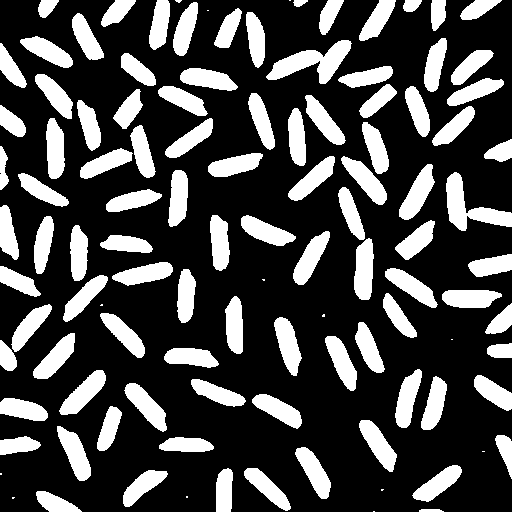

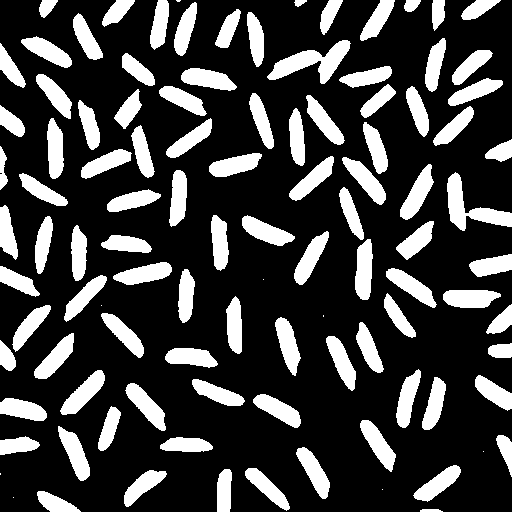

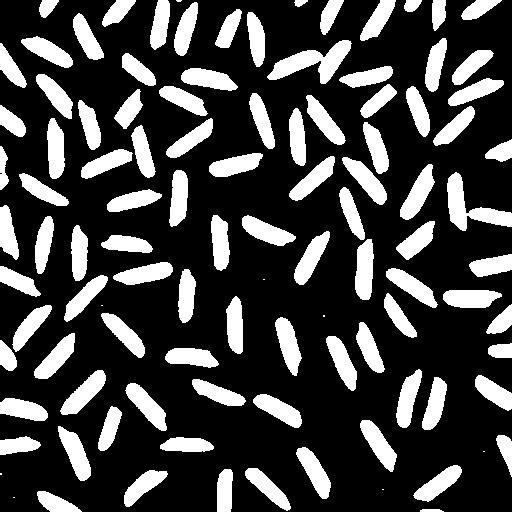

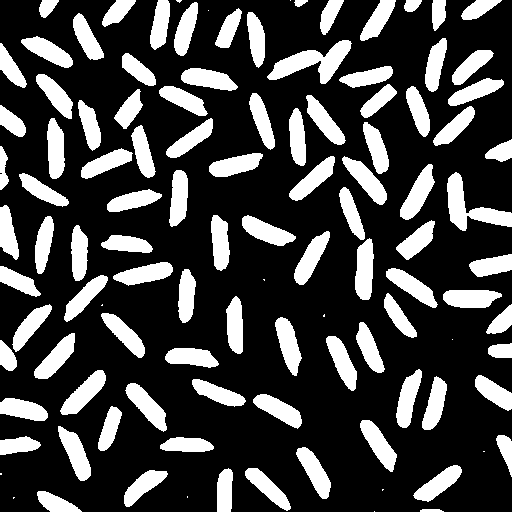

In [ ]:
# cv2_imshow(img)
cv2_imshow(dil)
cv2_imshow(ero)
cv2_imshow(ope)
cv2_imshow(cls)

In [ ]:
# (cv2.dilate(img,np.ones((5,5),np.uint8),iterations = 3) == DilateBinary(img,iter = 3)).sum()//512

In [ ]:
# (cv2.erode(img,np.ones((5,5),np.uint8),iterations = 3) == ErodeBinary(img,iter = 3)).sum()//512

In [ ]:
# (cv2.morphologyEx(img,cv2.MORPH_OPEN,np.ones((5,5),np.uint8),iterations = 3) == OpenBinary(img,iter = 3)).sum()//512

In [ ]:
# (cv2.morphologyEx(img,cv2.MORPH_CLOSE,np.ones((5,5),np.uint8),iterations = 3) == CloseBinary(img,iter = 3)).sum()//512